# Task 2: ResNet-50 Final Training Pipeline

**AI4ALL Team 9C — Synthetic Sight**

This notebook turns the ResNet-50 experiment into a repeatable final training process. It trains and validates every epoch, records training loss, validation loss, accuracy, precision, recall, and F1, and saves the best checkpoint to `best_resnet50.pth`.

It is self-contained: it reuses the same conventions, helpers, and shared train/validation sample as the exploration notebook, so its numbers stay comparable to the other models.

**Before running:** set the runtime to GPU (Runtime -> Change runtime type -> T4 GPU) and store your Kaggle token in Colab Secrets under `KAGGLE_API_TOKEN`.

Run order is top to bottom.

## 1. Install packages

In [1]:
!pip install -q kaggle kagglehub

## 2. Imports, labels, seed, and shared helpers

Shared settings and helper functions from the team's exploration notebook, copied so this notebook runs on its own. Real = 0, Fake = 1, and Fake is the positive class for precision, recall, and F1.

In [2]:
# *** IMPORTS ***

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# *** GLOBAL CONSTANTS ***

SEED = 42

REAL_LABEL = 0
FAKE_LABEL = 1
CLASS_NAMES = ["Real", "Fake"]

TRAIN_SAMPLES_PER_CLASS = 5000
VALID_SAMPLES_PER_CLASS = 1000
NEURAL_NETWORK_BATCH_SIZE = 32


def seed_everything(seed=SEED):
    """Standardize random seeds across libraries for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)


def create_seeded_data_loader(dataset, batch_size=NEURAL_NETWORK_BATCH_SIZE, shuffle=False, seed=SEED):
    """Create a reproducible PyTorch DataLoader."""
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
    )


def make_balanced_sample(real_paths, fake_paths, samples_per_class, seed=SEED):
    """Select equal numbers of real and fake paths and shuffle them together."""
    if len(real_paths) < samples_per_class or len(fake_paths) < samples_per_class:
        raise ValueError("The requested sample is larger than one of the classes.")

    python_rng = random.Random(seed)
    selected_real_paths = python_rng.sample(list(real_paths), samples_per_class)
    selected_fake_paths = python_rng.sample(list(fake_paths), samples_per_class)

    selected_paths = selected_real_paths + selected_fake_paths
    selected_targets = np.array(
        [REAL_LABEL] * samples_per_class + [FAKE_LABEL] * samples_per_class,
        dtype=np.int64,
    )

    shuffle_order = np.random.default_rng(seed).permutation(len(selected_paths))
    shuffled_paths = [selected_paths[index] for index in shuffle_order]
    shuffled_targets = selected_targets[shuffle_order]

    return shuffled_paths, shuffled_targets


def calculate_classification_metrics(experiment_name, true_targets, predicted_targets):
    """Return the main classification metrics, with Fake as the positive class."""
    return {
        "Experiment": experiment_name,
        "Evaluation split": "Official validation sample",
        "Validation images": int(len(true_targets)),
        "Accuracy": accuracy_score(true_targets, predicted_targets),
        "Fake precision": precision_score(true_targets, predicted_targets, pos_label=FAKE_LABEL, zero_division=0),
        "Fake recall": recall_score(true_targets, predicted_targets, pos_label=FAKE_LABEL, zero_division=0),
        "Fake F1": f1_score(true_targets, predicted_targets, pos_label=FAKE_LABEL, zero_division=0),
    }


seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Seed: {SEED}")
print(f"Label convention: Real = {REAL_LABEL}, Fake = {FAKE_LABEL}")
print(f"PyTorch device: {DEVICE}")

Seed: 42
Label convention: Real = 0, Fake = 1
PyTorch device: cuda


## 3. Download the dataset from Kaggle

Uses the **140k Real and Fake Faces** dataset. The token is read from Colab Secrets and only copied into the temporary runtime.

In [3]:
from google.colab import userdata
import subprocess

DATASET_ROOT = Path("/content/real_vs_fake/real-vs-fake")


def download_kaggle_dataset(dataset_name="xhlulu/140k-real-and-fake-faces", download_directory=Path("/content")):
    """Download and unzip the Kaggle dataset into the Colab runtime."""
    if DATASET_ROOT.exists():
        print(f"Dataset already found at: {DATASET_ROOT}")
        return

    kaggle_token = userdata.get("KAGGLE_API_TOKEN")
    if not kaggle_token:
        raise ValueError("KAGGLE_API_TOKEN was not found in Colab Secrets.")

    kaggle_directory = Path.home() / ".kaggle"
    kaggle_directory.mkdir(parents=True, exist_ok=True)

    token_path = kaggle_directory / "access_token"
    token_path.write_text(kaggle_token)
    token_path.chmod(0o600)

    print(f"Downloading Kaggle dataset: {dataset_name}")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", dataset_name, "--unzip", "-p", str(download_directory)],
        check=True,
    )
    print("Dataset download and extraction complete.")


download_kaggle_dataset()

Dataset download and extraction complete.


## 4. Locate the dataset images

Uses the official train and valid folders. The test folder stays untouched so it can be reserved for final evaluation later.

In [17]:
TRAIN_REAL_DIRECTORY = DATASET_ROOT / "train" / "real"
TRAIN_FAKE_DIRECTORY = DATASET_ROOT / "train" / "fake"

VALID_REAL_DIRECTORY = DATASET_ROOT / "valid" / "real"
VALID_FAKE_DIRECTORY = DATASET_ROOT / "valid" / "fake"

TEST_REAL_DIRECTORY = DATASET_ROOT / "test" / "real"
TEST_FAKE_DIRECTORY = DATASET_ROOT / "test" / "fake"


def list_image_paths(directory):
    """Return sorted image paths from one class directory."""
    return sorted(
        path for path in directory.glob("*")
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )


train_real_paths = list_image_paths(TRAIN_REAL_DIRECTORY)
train_fake_paths = list_image_paths(TRAIN_FAKE_DIRECTORY)

valid_real_paths = list_image_paths(VALID_REAL_DIRECTORY)
valid_fake_paths = list_image_paths(VALID_FAKE_DIRECTORY)

test_real_paths = list_image_paths(TEST_REAL_DIRECTORY)
test_fake_paths = list_image_paths(TEST_FAKE_DIRECTORY)

dataset_count_table = pd.DataFrame(
    [
        {"Split": "Train", "Real": len(train_real_paths), "Fake": len(train_fake_paths)},
        {"Split": "Valid", "Real": len(valid_real_paths), "Fake": len(valid_fake_paths)},
    ]
)
display(dataset_count_table)

,Split,Real,Fake
0,Train,50000,50000
1,Valid,10000,10000


## 5. Build the shared balanced sample

The same reproducible 5,000-per-class training sample and 1,000-per-class validation sample used across the team's experiments.

In [5]:
project_train_paths, project_train_targets = make_balanced_sample(
    train_real_paths, train_fake_paths, samples_per_class=TRAIN_SAMPLES_PER_CLASS, seed=SEED,
)

project_valid_paths, project_valid_targets = make_balanced_sample(
    valid_real_paths, valid_fake_paths, samples_per_class=VALID_SAMPLES_PER_CLASS, seed=SEED,
)

shared_sample_summary = pd.DataFrame(
    [
        {
            "Split": "Training",
            "Total images": len(project_train_paths),
            "Real": int((project_train_targets == REAL_LABEL).sum()),
            "Fake": int((project_train_targets == FAKE_LABEL).sum()),
        },
        {
            "Split": "Validation",
            "Total images": len(project_valid_paths),
            "Real": int((project_valid_targets == REAL_LABEL).sum()),
            "Fake": int((project_valid_targets == FAKE_LABEL).sum()),
        },
    ]
)
display(shared_sample_summary)

assert len(set(project_train_paths).intersection(project_valid_paths)) == 0
print("Training and validation paths do not overlap.")

,Split,Total images,Real,Fake
0,Training,10000,5000,5000
1,Validation,2000,1000,1000


Training and validation paths do not overlap.


In [18]:
TEST_SAMPLES_PER_CLASS = 1000

project_test_paths, project_test_targets = make_balanced_sample(
    test_real_paths,
    test_fake_paths,
    samples_per_class=TEST_SAMPLES_PER_CLASS,
    seed=SEED,
)

resnet50_test_dataset = FacePathDataset(
    project_test_paths,
    project_test_targets,
    resnet50_transform,
)

resnet50_test_loader = create_seeded_data_loader(
    resnet50_test_dataset,
    shuffle=False
)

print(f"ResNet-50 test images: {len(resnet50_test_dataset)}")

ResNet-50 test images: 2000


## 6. ResNet-50 datasets

ResNet expects 224x224 images normalized with the ImageNet mean and standard deviation. The same shared paths are used, only the transform differs.

In [6]:
class FacePathDataset(Dataset):
    """Load an image from its path and return a numeric target."""

    def __init__(self, image_paths, numeric_targets, image_transform):
        if len(image_paths) != len(numeric_targets):
            raise ValueError("Image paths and targets must have equal length.")
        self.image_paths = list(image_paths)
        self.numeric_targets = np.asarray(numeric_targets, dtype=np.int64)
        self.image_transform = image_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            rgb_image = image.convert("RGB")
        transformed_image = self.image_transform(rgb_image)
        numeric_target = torch.tensor(self.numeric_targets[index], dtype=torch.float32)
        return transformed_image, numeric_target


RESNET_IMAGE_SIZE = (224, 224)

resnet50_transform = transforms.Compose(
    [
        transforms.Resize(RESNET_IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

resnet50_train_dataset = FacePathDataset(project_train_paths, project_train_targets, resnet50_transform)
resnet50_valid_dataset = FacePathDataset(project_valid_paths, project_valid_targets, resnet50_transform)

print(f"ResNet-50 training images: {len(resnet50_train_dataset)}")
print(f"ResNet-50 validation images: {len(resnet50_valid_dataset)}")

ResNet-50 training images: 10000
ResNet-50 validation images: 2000


## 7. Training pipeline (builder + train/validate function)

`build_resnet50_transfer_model` creates a fresh frozen-backbone model with a new binary head every run, which is what makes training repeatable.

`train_and_validate_resnet50` runs both a train pass and a validation pass each epoch, records all required metrics, and saves the best epoch to `best_resnet50.pth`.

In [7]:
def build_resnet50_transfer_model(device):
    """
    Build a fresh ResNet-50 with a frozen ImageNet backbone and a new binary
    head. Building from scratch each run is what makes the pipeline repeatable.
    """
    seed_everything()

    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)

    # Freeze the backbone. Only the new head will learn.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Replace the ImageNet head with a small binary head.
    # One output logit: negative leans Real, positive leans Fake.
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.40),
        nn.Linear(256, 1),
    )

    return model.to(device)


def train_and_validate_resnet50(
    model,
    train_loader,
    valid_loader,
    loss_function,
    optimizer,
    device,
    epoch_count=10,
    checkpoint_path="best_resnet50.pth",
    monitor_metric="Fake F1",
    early_stopping_patience=None,
):
    """
    Train and validate a one-logit binary model every epoch.

    Returns a DataFrame with one row per epoch (train loss, val loss, accuracy,
    Fake precision, Fake recall, Fake F1). The best epoch by monitor_metric is
    saved to checkpoint_path, and the best weights are reloaded at the end.
    """
    history_rows = []
    best_metric_value = float("-inf")
    epochs_without_improvement = 0

    for epoch_index in range(epoch_count):

        # ---- Training phase ----
        # Keep the frozen backbone in eval mode so its BatchNorm layers use the
        # ImageNet running statistics instead of updating on our small sample.
        # Put only the head in train mode so its Dropout is active.
        model.eval()
        model.fc.train()

        running_train_loss = 0.0
        for batch_images, batch_targets in train_loader:
            batch_images = batch_images.to(device)
            batch_targets = batch_targets.to(device).float().view(-1, 1)

            optimizer.zero_grad()
            logits = model(batch_images)
            loss = loss_function(logits, batch_targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        average_train_loss = running_train_loss / len(train_loader)

        # ---- Validation phase ----
        model.eval()
        running_valid_loss = 0.0
        collected_targets = []
        collected_predictions = []

        with torch.no_grad():
            for batch_images, batch_targets in valid_loader:
                batch_images = batch_images.to(device)
                batch_targets = batch_targets.to(device).float().view(-1, 1)

                logits = model(batch_images)
                running_valid_loss += loss_function(logits, batch_targets).item()

                fake_probabilities = torch.sigmoid(logits).view(-1)
                batch_predictions = (fake_probabilities >= 0.50).to(torch.int64)

                collected_targets.extend(batch_targets.view(-1).cpu().numpy().astype(int))
                collected_predictions.extend(batch_predictions.cpu().numpy().astype(int))

        average_valid_loss = running_valid_loss / len(valid_loader)

        metrics = calculate_classification_metrics(
            "ResNet-50 transfer learning", collected_targets, collected_predictions
        )

        history_rows.append(
            {
                "Epoch": epoch_index + 1,
                "Train loss": average_train_loss,
                "Val loss": average_valid_loss,
                "Accuracy": metrics["Accuracy"],
                "Fake precision": metrics["Fake precision"],
                "Fake recall": metrics["Fake recall"],
                "Fake F1": metrics["Fake F1"],
            }
        )

        print(
            f"Epoch {epoch_index + 1:02d}/{epoch_count}  "
            f"train loss {average_train_loss:.4f}  "
            f"val loss {average_valid_loss:.4f}  "
            f"acc {metrics['Accuracy']:.4f}  "
            f"Fake F1 {metrics['Fake F1']:.4f}"
        )

        # ---- Checkpoint the best epoch ----
        current_metric_value = metrics[monitor_metric]
        if current_metric_value > best_metric_value:
            best_metric_value = current_metric_value
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch_index + 1,
                    "monitor_metric": monitor_metric,
                    "monitor_value": best_metric_value,
                    "decision_threshold": 0.50,
                    "label_convention": {"Real": REAL_LABEL, "Fake": FAKE_LABEL},
                    "class_names": CLASS_NAMES,
                    "image_size": (224, 224),
                    "normalize_mean": [0.485, 0.456, 0.406],
                    "normalize_std": [0.229, 0.224, 0.225],
                },
                checkpoint_path,
            )
            print(f"  saved new best checkpoint ({monitor_metric} = {best_metric_value:.4f})")
        else:
            epochs_without_improvement += 1

        # ---- Optional early stopping ----
        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping: no improvement in {monitor_metric} for {early_stopping_patience} epochs.")
            break

    # Reload the best weights so the returned model matches the saved file.
    best_checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    print(f"\nBest epoch: {best_checkpoint['epoch']} ({monitor_metric} = {best_checkpoint['monitor_value']:.4f})")

    return pd.DataFrame(history_rows)

## 8. Run the pipeline

Monitoring Fake F1 balances catching fakes against false accusations. Switch `monitor_metric` to `"Fake recall"` if the team decides missing a fake is worse than a false alarm.

**Note:** `best_resnet50.pth` saves to the temporary Colab runtime. Download it (or mount Google Drive and point `checkpoint_path` there) so it survives a disconnect.

In [8]:
# Fresh, seeded loaders.
resnet50_train_loader = create_seeded_data_loader(resnet50_train_dataset, shuffle=True, seed=SEED)
resnet50_valid_loader = create_seeded_data_loader(resnet50_valid_dataset, shuffle=False)

# Fresh model, loss, and optimizer (only the head is trainable).
resnet50_transfer_model = build_resnet50_transfer_model(DEVICE)
resnet50_loss_function = nn.BCEWithLogitsLoss()
resnet50_optimizer = torch.optim.Adam(resnet50_transfer_model.fc.parameters(), lr=0.0005)

resnet50_training_history = train_and_validate_resnet50(
    model=resnet50_transfer_model,
    train_loader=resnet50_train_loader,
    valid_loader=resnet50_valid_loader,
    loss_function=resnet50_loss_function,
    optimizer=resnet50_optimizer,
    device=DEVICE,
    epoch_count=10,
    checkpoint_path="best_resnet50.pth",
    monitor_metric="Fake F1",
    early_stopping_patience=3,
)

# Save per-epoch history so Task 10 (visualizations) can plot it directly.
resnet50_training_history.to_csv("resnet50_training_history.csv", index=False)

display(resnet50_training_history.round(4))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Epoch 01/10  train loss 0.4412  val loss 0.3547  acc 0.8490  Fake F1 0.8442
  saved new best checkpoint (Fake F1 = 0.8442)
Epoch 02/10  train loss 0.3017  val loss 0.3057  acc 0.8740  Fake F1 0.8708
  saved new best checkpoint (Fake F1 = 0.8708)
Epoch 03/10  train loss 0.2563  val loss 0.2793  acc 0.8830  Fake F1 0.8842
  saved new best checkpoint (Fake F1 = 0.8842)
Epoch 04/10  train loss 0.2232  val loss 0.2655  acc 0.8940  Fake F1 0.8947
  saved new best checkpoint (Fake F1 = 0.8947)
Epoch 05/10  train loss 0.2012  val loss 0.2629  acc 0.8905  Fake F1 0.8907
Epoch 06/10  train loss 0.1848  val loss 0.2576  acc 0.8950  Fake F1 0.8968
  saved new best checkpoint (Fake F1 = 0.8968)
Epoch 07/10  train loss 0.1705  val loss 0.2614  acc 0.8925  Fake F1 0.8909
Epoch 08/10  train loss 0.1575  val loss 0.2798  acc 0.8910  Fake F1 0.8865
Epoch 09/10  train loss 0.1356  val loss 0.2575  acc 0.8985  Fake F1 0.8987
  saved new best checkpoint (Fake F1 = 0.8987)
Epoch 10/10  train loss 0.1253  va

,Epoch,Train loss,Val loss,Accuracy,Fake precision,Fake recall,Fake F1
0,1,0.4412,0.3547,0.8490,0.8721,0.818,0.8442
1,2,0.3017,0.3057,0.8740,0.8937,0.849,0.8708
2,3,0.2563,0.2793,0.8830,0.8755,0.893,0.8842
3,4,0.2232,0.2655,0.8940,0.8886,0.901,0.8947
4,5,0.2012,0.2629,0.8905,0.8893,0.892,0.8907
5,6,0.1848,0.2576,0.8950,0.8820,0.912,0.8968
6,7,0.1705,0.2614,0.8925,0.9042,0.878,0.8909
7,8,0.1575,0.2798,0.8910,0.9250,0.851,0.8865
8,9,0.1356,0.2575,0.8985,0.8973,0.900,0.8987
9,10,0.1253,0.2922,0.8910,0.8510,0.948,0.8969


## 9. Confusion matrix for the best model

A quick visual check of where the final model makes mistakes on the validation sample.

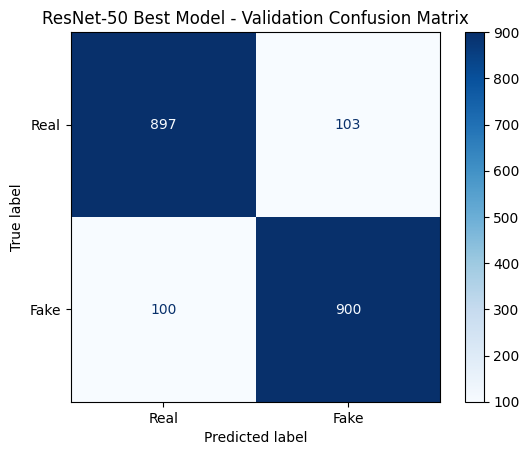

In [9]:
resnet50_transfer_model.eval()
final_targets = []
final_predictions = []

with torch.no_grad():
    for batch_images, batch_targets in resnet50_valid_loader:
        batch_images = batch_images.to(DEVICE)
        logits = resnet50_transfer_model(batch_images)
        fake_probabilities = torch.sigmoid(logits).view(-1)
        batch_predictions = (fake_probabilities >= 0.50).to(torch.int64)

        final_targets.extend(batch_targets.view(-1).cpu().numpy().astype(int))
        final_predictions.extend(batch_predictions.cpu().numpy().astype(int))

ConfusionMatrixDisplay.from_predictions(final_targets, final_predictions, display_labels=CLASS_NAMES, cmap="Blues")
plt.title("ResNet-50 Best Model - Validation Confusion Matrix")
plt.show()

In [10]:
def evaluate_model(model, loader, device, threshold=0.50):

    model.eval()

    targets = []
    probabilities = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            probs = torch.sigmoid(logits).view(-1)

            targets.extend(labels.numpy().astype(int))
            probabilities.extend(probs.cpu().numpy())

    probabilities = np.array(probabilities)
    targets = np.array(targets)

    predictions = (probabilities >= threshold).astype(int)

    return {
        "targets": targets,
        "probabilities": probabilities,
        "predictions": predictions,
    }

In [11]:
validation_results = evaluate_model(
    resnet50_transfer_model,
    resnet50_valid_loader,
    DEVICE
)

In [15]:
threshold_results = []

for threshold in np.arange(0.10,0.91,0.05):

    predictions = (
        validation_results["probabilities"] >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy":
            accuracy_score(
                validation_results["targets"],
                predictions
            ),

        "Precision":
            precision_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            ),

        "Recall":
            recall_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            ),

        "F1":
            f1_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            )

    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.8560,0.783892,0.983,0.872227
1,0.15,0.8705,0.806959,0.974,0.882646
2,0.20,0.8840,0.832180,0.962,0.892393
3,0.25,0.8895,0.846222,0.952,0.896000
4,0.30,0.8940,0.858834,0.943,0.898951
5,0.35,0.8970,0.867593,0.937,0.900962
6,0.40,0.8990,0.875706,0.930,0.902037
7,0.45,0.9015,0.887923,0.919,0.903194
8,0.50,0.8985,0.897308,0.900,0.898652
9,0.55,0.8995,0.905584,0.892,0.898741


In [14]:
best_threshold = threshold_table.loc[
    threshold_table["F1"].idxmax(),
    "Threshold"
]

best_row = threshold_table.loc[
    threshold_table["F1"].idxmax()
]

display(best_row)

best_threshold = float(best_row["Threshold"])

print(f"Selected threshold: {best_threshold:.2f}")

,7
Threshold,0.450000
Accuracy,0.901500
Precision,0.887923
Recall,0.919000
F1,0.903194


Selected threshold: 0.45


In [22]:
# Reload best model before test evaluation
checkpoint = torch.load(
    "best_resnet50.pth",
    map_location=DEVICE
)

resnet50_transfer_model.load_state_dict(
    checkpoint["model_state_dict"]
)

resnet50_transfer_model.eval()

print("Loaded best ResNet-50 checkpoint")

Loaded best ResNet-50 checkpoint


In [20]:
test_results = evaluate_model(
    resnet50_transfer_model,
    resnet50_test_loader,
    DEVICE,
    threshold=best_threshold
)

In [21]:
test_accuracy = accuracy_score(
    test_results["targets"],
    test_results["predictions"]
)

test_precision = precision_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_recall = recall_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_f1 = f1_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_metrics = pd.DataFrame([{
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1
}])

display(test_metrics.round(4))

,Accuracy,Precision,Recall,F1
0,0.911,0.8998,0.925,0.9122
